<a href="https://colab.research.google.com/github/UrielBaldesco/Machine-Learning-Custom-Models/blob/main/ML_coding_assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [3]:
(dataset_train, dataset_test), dataset_info = tfds.load(
    'rock_paper_scissors',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/2520 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.3WCWRH_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...:   0%|          | 0/372 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.3WCWRH_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.


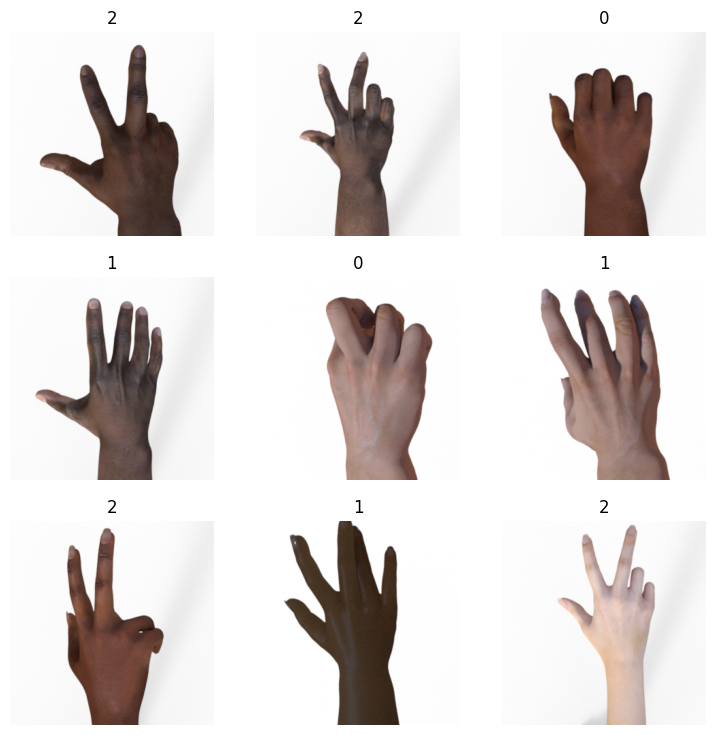

In [4]:
# visualize 9 images.
### No EDITS needed in this code block if previous block ran ###

plt.figure(figsize=(9, 9))
for i, (image, label) in enumerate(dataset_train.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(int(label))
    plt.axis("off")

First develop an MLP model. Since the images are represented by 2D matrices, it will be necessary to reshape each image to a 1D array (so, overall, the dataset is of shape (len(data), 300*300). But we want to reduce the complexity, especially since the MLP is not ideal for this and we are generating a large, 1D array when flattening.

In [5]:
### No EDITS needed in this code block if previous block ran. This is educational ###

def preprocess_and_flatten(image, label):
    print(f'shape of image in original: {image.shape}')
    image = tf.image.resize(image, [150, 150])
    # Convert to grayscale
    image = tf.image.rgb_to_grayscale(image)
    # Normalize the image
    image = tf.cast(image, tf.float32) / 255.0
    # Flatten the image to a 1D tensor
    image = tf.reshape(image, [-1])
    print(f"After flattening, image shape: {image.shape}")
    return image, label

# Apply the preprocessing function to the dataset
mlp_train = dataset_train.map(preprocess_and_flatten)
mlp_test = dataset_test.map(preprocess_and_flatten)

# Batch and prefetch the dataset for optimal performance. The prefetch is relevent when working with lage datasets
# as expensive processing hardware must be used to perform the matrix operations and should be used optimally. GPUs or TPUs
# should not run idle once the training has begun. The method for retreiving the data, then, becomes very important
# and this consideration is less relevant with the smaller datasets we have worked with at this point.But I wanted to
# show that this is essential in the real world of big data, and here we're creating a scenario that's artificially making
# the data bigger and suboptimal for demonstration. We will balance this out a bit with the following code:

# use this data for the mlp #
BATCH_SIZE = 32
mlp_train = mlp_train.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
mlp_test = mlp_test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

shape of image in original: (300, 300, 3)
After flattening, image shape: (22500,)
shape of image in original: (300, 300, 3)
After flattening, image shape: (22500,)


Build an MLP Model that Computes an Appropriate Performance Metric



In [6]:
from tensorflow.keras.metrics import AUC
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Conv2D, LeakyReLU, MaxPooling2D, Flatten, Dense

model_mlp = models.Sequential()
model_mlp.add(layers.InputLayer(shape=(150 * 150,)))
model_mlp.add(layers.Dense(128))
model_mlp.add(layers.LeakyReLU(0.1))
# model_mlp.add(Dense(512, activation='relu', input_shape=(22500,))),
model_mlp.add(Dense(64)),
model_mlp.add(Dense(3, activation='softmax'))
    ### EDIT Needed, add layers including a suitable output layer, given the number of classes (e.g. 3)
    ### EDIT Needed

model_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model_mlp.fit(
    mlp_train,
    epochs=10,  # You can adjust the number of epochs
    validation_data=mlp_test
)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.3985 - loss: 20.3435 - val_accuracy: 0.4489 - val_loss: 1.3872
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7026 - loss: 0.7146 - val_accuracy: 0.4113 - val_loss: 1.9854
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7095 - loss: 0.6977 - val_accuracy: 0.5887 - val_loss: 0.9833
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8567 - loss: 0.3988 - val_accuracy: 0.4597 - val_loss: 1.6056
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8442 - loss: 0.4032 - val_accuracy: 0.5780 - val_loss: 1.1677
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9036 - loss: 0.2832 - val_accuracy: 0.6720 - val_loss: 1.1384
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9306 - loss: 0.2238 - val_accuracy: 0.6855 - val_loss: 1.2701
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9129 - loss: 0.2429 - val_accuracy: 0.4973 

Plot Training/Validation Performance Curves and Describe Result





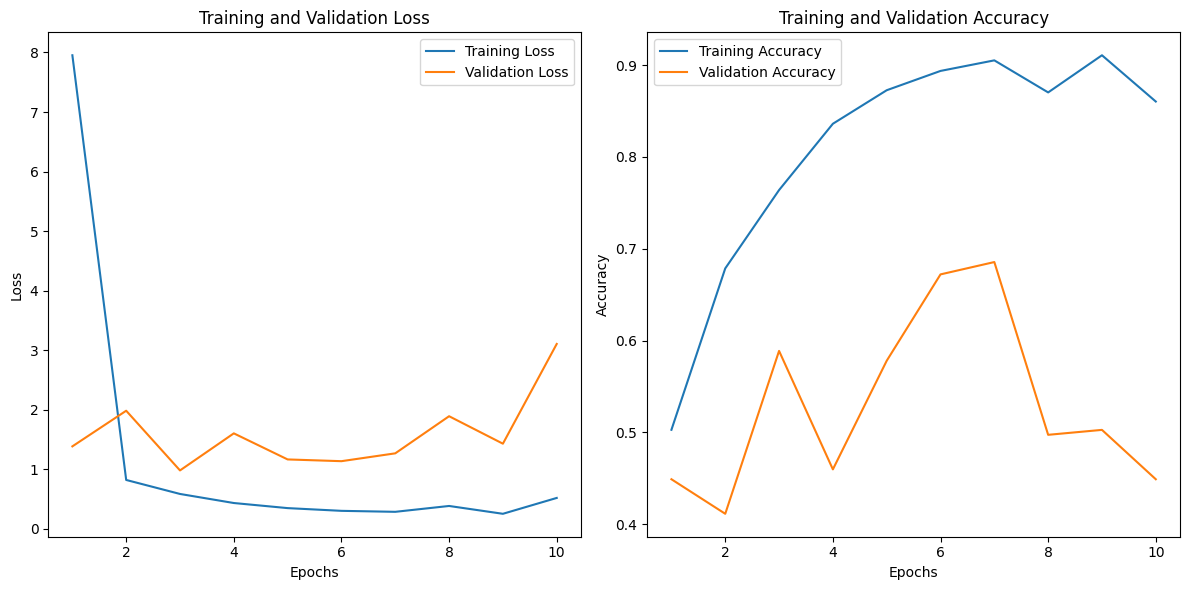

In [7]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Description**
- The result of each epoch shows an improvement of the multi-layer perceptron with an accuracy of 92% by the 10th epoch.
- The training loss decreased sharply, whereas the validation loss maintained a stable trajectory. This means that the MLP performed well on the training set, and also performed decent on the validation set.
- The training accuracy increased, whereas the validation accuracy increased and decreased indicating less accuracy on the validation set. This means that there is overfitting happening and the MLP is memorizing noise rather than generalizing to new data.

**Build a CNN Model that Computes an Appropiate Performance Metric**

Now, see if using image specific layers,for instance, the Conv2D, improve the classification performance

In [8]:
# Basic preprocessing: Resize images and normalize
from tensorflow.keras.layers import Rescaling

def preprocess(image, label):
    resized_image =  tf.image.resize(image, [150,150])# ?? EDIT needed. Resize images so that they are smaller. Look in this notebook for a solution
    #   image = tf.image.resize(image, [150, 150])

    #Normalize the pixel intensity values
    return Rescaling(1/255)(resized_image), label
    # Note on rescaling: pixel intensities range from 1-255
    #"Rescaling(?? EDIT needed)" is expecting a scaling factor, 1 / ??

# Apply preprocessing to dataset
# use this data for the section where you build a CNN model
BATCH_SIZE=32
cnn_train = dataset_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)# ?? EDIT).shuffle(1000) Set batch size. Often, a good start is 32
cnn_test = dataset_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)# ?? EDIT)

In [1]:
from tensorflow.keras import layers, models
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Conv2D, LeakyReLU, MaxPooling2D, Flatten, Dense, Dropout

# Define the CNN model
cnn_model = models.Sequential()
cnn_model.add(Conv2D(filters=16, kernel_size=(3,3), padding='same', input_shape=(150, 150, 3)))
cnn_model.add(LeakyReLU(0.1))
# cnn_model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same'))
# cnn_model.add(LeakyReLU(0.1))
cnn_model.add(Dropout(0.5))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(Flatten())
cnn_model.add(Dense(64))
cnn_model.add(LeakyReLU(0.1))
cnn_model.add(Dense(3, activation='softmax'))

    # layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    # . . . EDITS Needed (for example, add layers, make an output layer with the number of classes, e.g. 3)



# Compile the model
cnn_model.compile(optimizer='adam',
              # the true labels are not one-hot-encoded tensors (0, 0, 1) but integers so we use "sparse"
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Model summary
cnn_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 150, 150, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 150, 150, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 90000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       5,760,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,760,707 (21.98 MB)

 Trainable params: 5,760,707 (21.98 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
cnn_history = cnn_model.fit(
    cnn_train,
    epochs=5,  # You can adjust the number of epochs, keep low unless you have a compute cluster (AWS, Colab Pro)
    validation_data=cnn_test
)

Epoch 1/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.5001 - loss: 16.4072 - val_accuracy: 0.6102 - val_loss: 0.8260
Epoch 2/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9750 - loss: 0.1507 - val_accuracy: 0.6344 - val_loss: 0.7495
Epoch 3/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9960 - loss: 0.0388 - val_accuracy: 0.7177 - val_loss: 0.7544
Epoch 4/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9991 - loss: 0.0172 - val_accuracy: 0.6909 - val_loss: 0.7593
Epoch 5/5
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9981 - loss: 0.0124 - val_accuracy: 0.7339 - val_loss: 0.8289


**Plot Training/Validation Performance Curves and Describe Result**




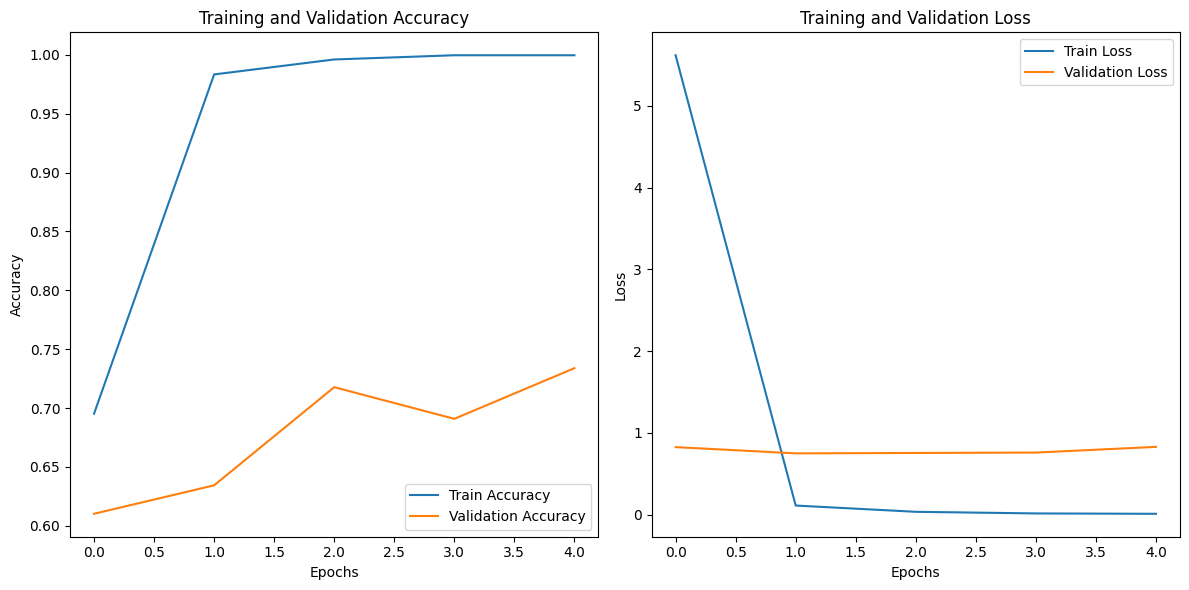

In [11]:
train_accuracy = cnn_history.history['accuracy']
val_accuracy = cnn_history.history['val_accuracy']

train_loss = cnn_history.history['loss']
val_loss = cnn_history.history['val_loss']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Description**
- The Training Accuracy shows a gradual increase then it stabilizes and reaches a 100% accuracy. The validation accuracy score increases gradually.
- The training loss is a sharp decrease then stabilizes and reaches a loss of 0. The validation loss maintains stable at a very low loss score. This means that the CNN was able to have its prediction match the ground truth for most of the epochs and the validation loss being at a low, stable score means that it generalized to new, unseen data successfully.